In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [10]:
df=pd.read_csv('/kaggle/input/datasets/vitthalbulbule/student-placement-data/students_data.csv')

In [4]:
df.head()

,cgpa,iq,placement
0,5.3,121,0
1,7.9,122,0
2,7.3,120,0
3,5.2,136,0
4,7.7,141,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    int64  
 2   placement  100 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 2.5 KB


In [6]:
import matplotlib.pyplot as plt

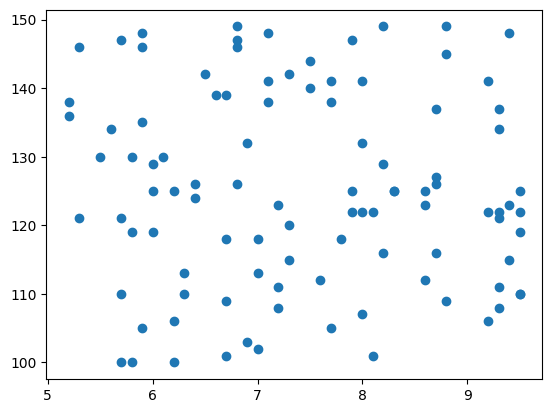

In [7]:
plt.scatter(df['cgpa'],df['iq'])

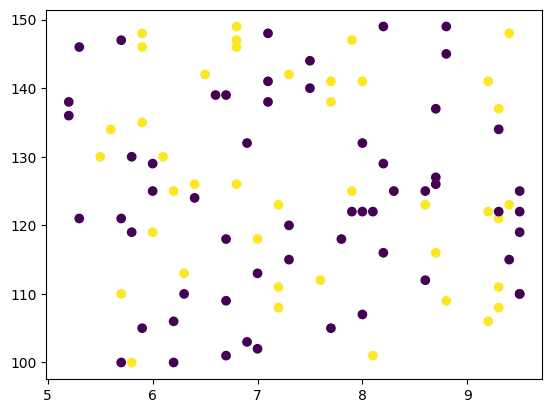

In [8]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [12]:
df1=pd.read_csv('/kaggle/input/datasets/vitthalbulbule/placement-student/students_data_logical.csv')

In [13]:
df1.shape

(100, 3)

In [14]:
df1.head()

,cgpa,iq,placement
0,9.0,104,0
1,8.8,140,0
2,7.2,132,0
3,8.5,121,0
4,7.5,126,0


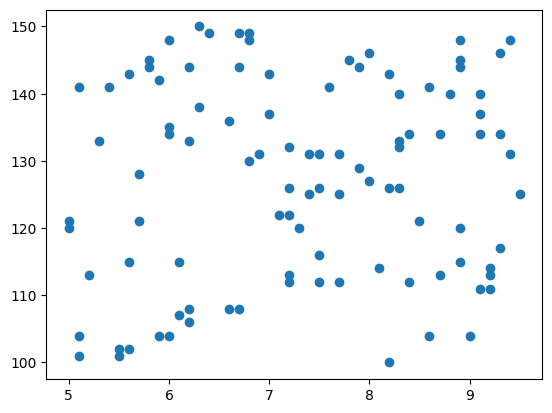

In [18]:
plt.scatter(df1['cgpa'],df1['iq'])

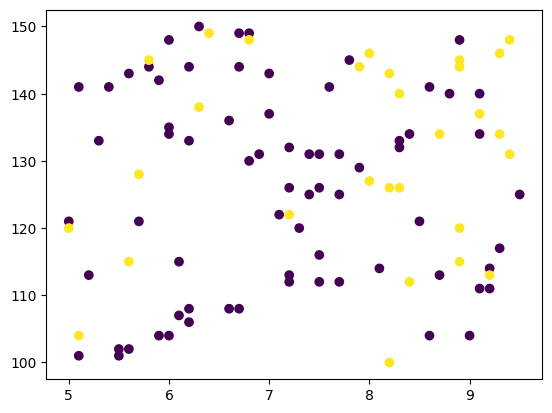

In [17]:
plt.scatter(df1['cgpa'],df1['iq'],c=df1['placement'])

In [20]:
X=df1.iloc[ : ,0:2]
Y=df1.iloc[ : ,-1]

In [21]:
X

,cgpa,iq
0,9.0,104
1,8.8,140
2,7.2,132
3,8.5,121
4,7.5,126
...,...,...
95,9.5,125
96,7.5,116
97,6.6,136
98,6.0,104


In [22]:
Y

0     0
1     0
2     0
3     0
4     0
     ..
95    0
96    0
97    0
98    0
99    0
Name: placement, Length: 100, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.1)

In [29]:
x_train

,cgpa,iq
64,8.6,104
7,7.7,131
46,5.5,101
52,8.9,145
26,7.7,112
...,...,...
91,5.1,141
68,5.7,121
63,9.2,113
25,6.0,135


In [30]:
x_test

,cgpa,iq
15,5.1,104
1,8.8,140
97,6.6,136
82,6.2,144
53,5.2,113
23,7.2,113
18,8.6,141
41,8.3,126
69,6.7,108
44,5.4,141


In [31]:
y_train

64    0
7     0
46    0
52    1
26    0
     ..
91    0
68    0
63    1
25    0
36    0
Name: placement, Length: 90, dtype: int64

In [32]:
y_test

15    1
1     0
97    0
82    0
53    0
23    0
18    0
41    1
69    0
44    0
Name: placement, dtype: int64

In [35]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

x_train=scaler.fit_transform(x_train)

In [36]:
x_train

array([[ 0.93280779, -1.5826232 ],
       [ 0.24529704,  0.2601053 ],
       [-1.43528478, -1.78737081],
       [ 1.16197804,  1.21559415],
       [ 0.24529704, -1.03662957],
       [ 1.54392846,  1.42034176],
       [-0.06026329, -0.49063594],
       [-1.3588947 , -0.83188196],
       [-1.8172352 , -0.49063594],
       [-0.59499387, -1.30962639],
       [ 0.0161268 , -0.14938992],
       [ 0.39807721,  1.14734495],
       [-0.13665337, -1.03662957],
       [-0.28943354,  1.07909574],
       [-0.4422137 ,  1.42034176],
       [ 0.16890696,  0.94259734],
       [-0.97694428, -0.83188196],
       [ 0.24529704, -0.14938992],
       [ 1.54392846,  0.2601053 ],
       [ 0.62724746,  1.07909574],
       [ 1.16197804, -0.49063594],
       [-1.05333437,  1.42034176],
       [-0.9005542 , -1.30962639],
       [-1.43528478, -1.71912161],
       [ 1.39114829, -1.10487877],
       [ 1.31475821,  0.87434813],
       [-0.74777403,  1.48859096],
       [-0.13665337, -0.35413753],
       [ 1.62031854,

In [37]:
x_test=scaler.transform(x_test)
x_test

array([[-1.74084511, -1.5826232 ],
       [ 1.08558796,  0.87434813],
       [-0.59499387,  0.60135132],
       [-0.9005542 ,  1.14734495],
       [-1.66445503, -0.96838037],
       [-0.13665337, -0.96838037],
       [ 0.93280779,  0.94259734],
       [ 0.70363754, -0.08114072],
       [-0.51860379, -1.30962639],
       [-1.51167486,  0.94259734]])

In [39]:
# Training the Model using logistic Regression

from sklearn.linear_model import LogisticRegression

clf=LogisticRegression()

clf.fit(x_train,y_train)



LogisticRegression()

In [45]:
y_pred=clf.predict(x_test)
y_pred

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0])

In [43]:
y_test

15    1
1     0
97    0
82    0
53    0
23    0
18    0
41    1
69    0
44    0
Name: placement, dtype: int64

In [47]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)


0.6

<Axes: >

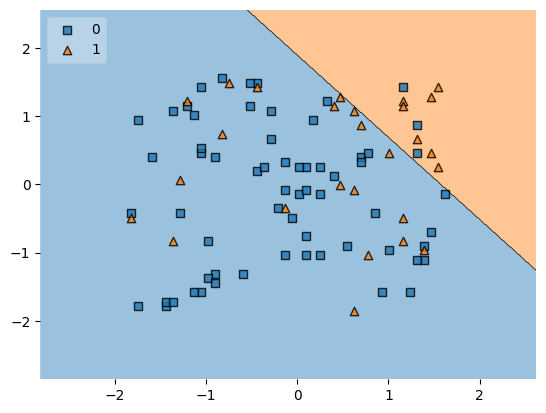

In [50]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [51]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))